In [1]:
import os 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
data_dir='C:\\Users\\lg\\Desktop\\IIT R PGC\\ML\\ML solutions datasets_10 codes\\ML solutions  Datasets\\Agglomerative clustering'
os.chdir(data_dir)

In [3]:
data=pd.read_csv("pollution_india_2010.csv",na_values='Null')

In [4]:
data.head()

,City,NO2,PM10,SO2,State
0,Chitoor,9.0,39.0,4.0,Andhra Pradesh
1,Guntur,11.0,81.0,2.0,Andhra Pradesh
2,Hydrabad,24.0,79.0,5.0,Andhra Pradesh
3,Kothagudem,11.0,62.0,2.0,Andhra Pradesh
4,Kurnool,9.0,85.0,4.0,Andhra Pradesh


In [5]:
data.isnull().sum()

City     0
NO2      4
PM10     1
SO2      5
State    0
dtype: int64

In [6]:
data.shape

(181, 5)

In [7]:
data=data.dropna()

In [8]:
data.shape

(175, 5)

In [9]:
data.dtypes

City      object
NO2      float64
PM10     float64
SO2      float64
State     object
dtype: object

In [12]:
data_pol = data.groupby('State', as_index=False)[['NO2', 'PM10', 'SO2']].sum()

In [13]:
data_pol.head()

,State,NO2,PM10,SO2
0,Andhra Pradesh,183.0,893.0,60.0
1,Assam,177.0,834.0,74.0
2,Bihar,40.0,181.0,7.0
3,Chandigarh,16.0,92.0,2.0
4,Chattisgarh,86.0,502.0,37.0


In [14]:
def scale(x):
    return(x-np.mean(x)/np.std(x))

In [16]:
data_num=data_pol.drop("State",axis=1)
data_scaled=data_num.apply(scale,axis=1)

In [18]:
data_scaled.head()

,NO2,PM10,SO2
0,181.968601,891.968601,58.968601
1,175.925615,832.925615,72.925615
2,38.992825,179.992825,5.992825
3,15.072712,91.072712,1.072712
4,85.001350,501.001350,36.001350


In [19]:
data_scaled.shape

(29, 3)

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [22]:
data_scaled=np.array(data_scaled)

In [27]:
Z=linkage(data_scaled,method="ward")

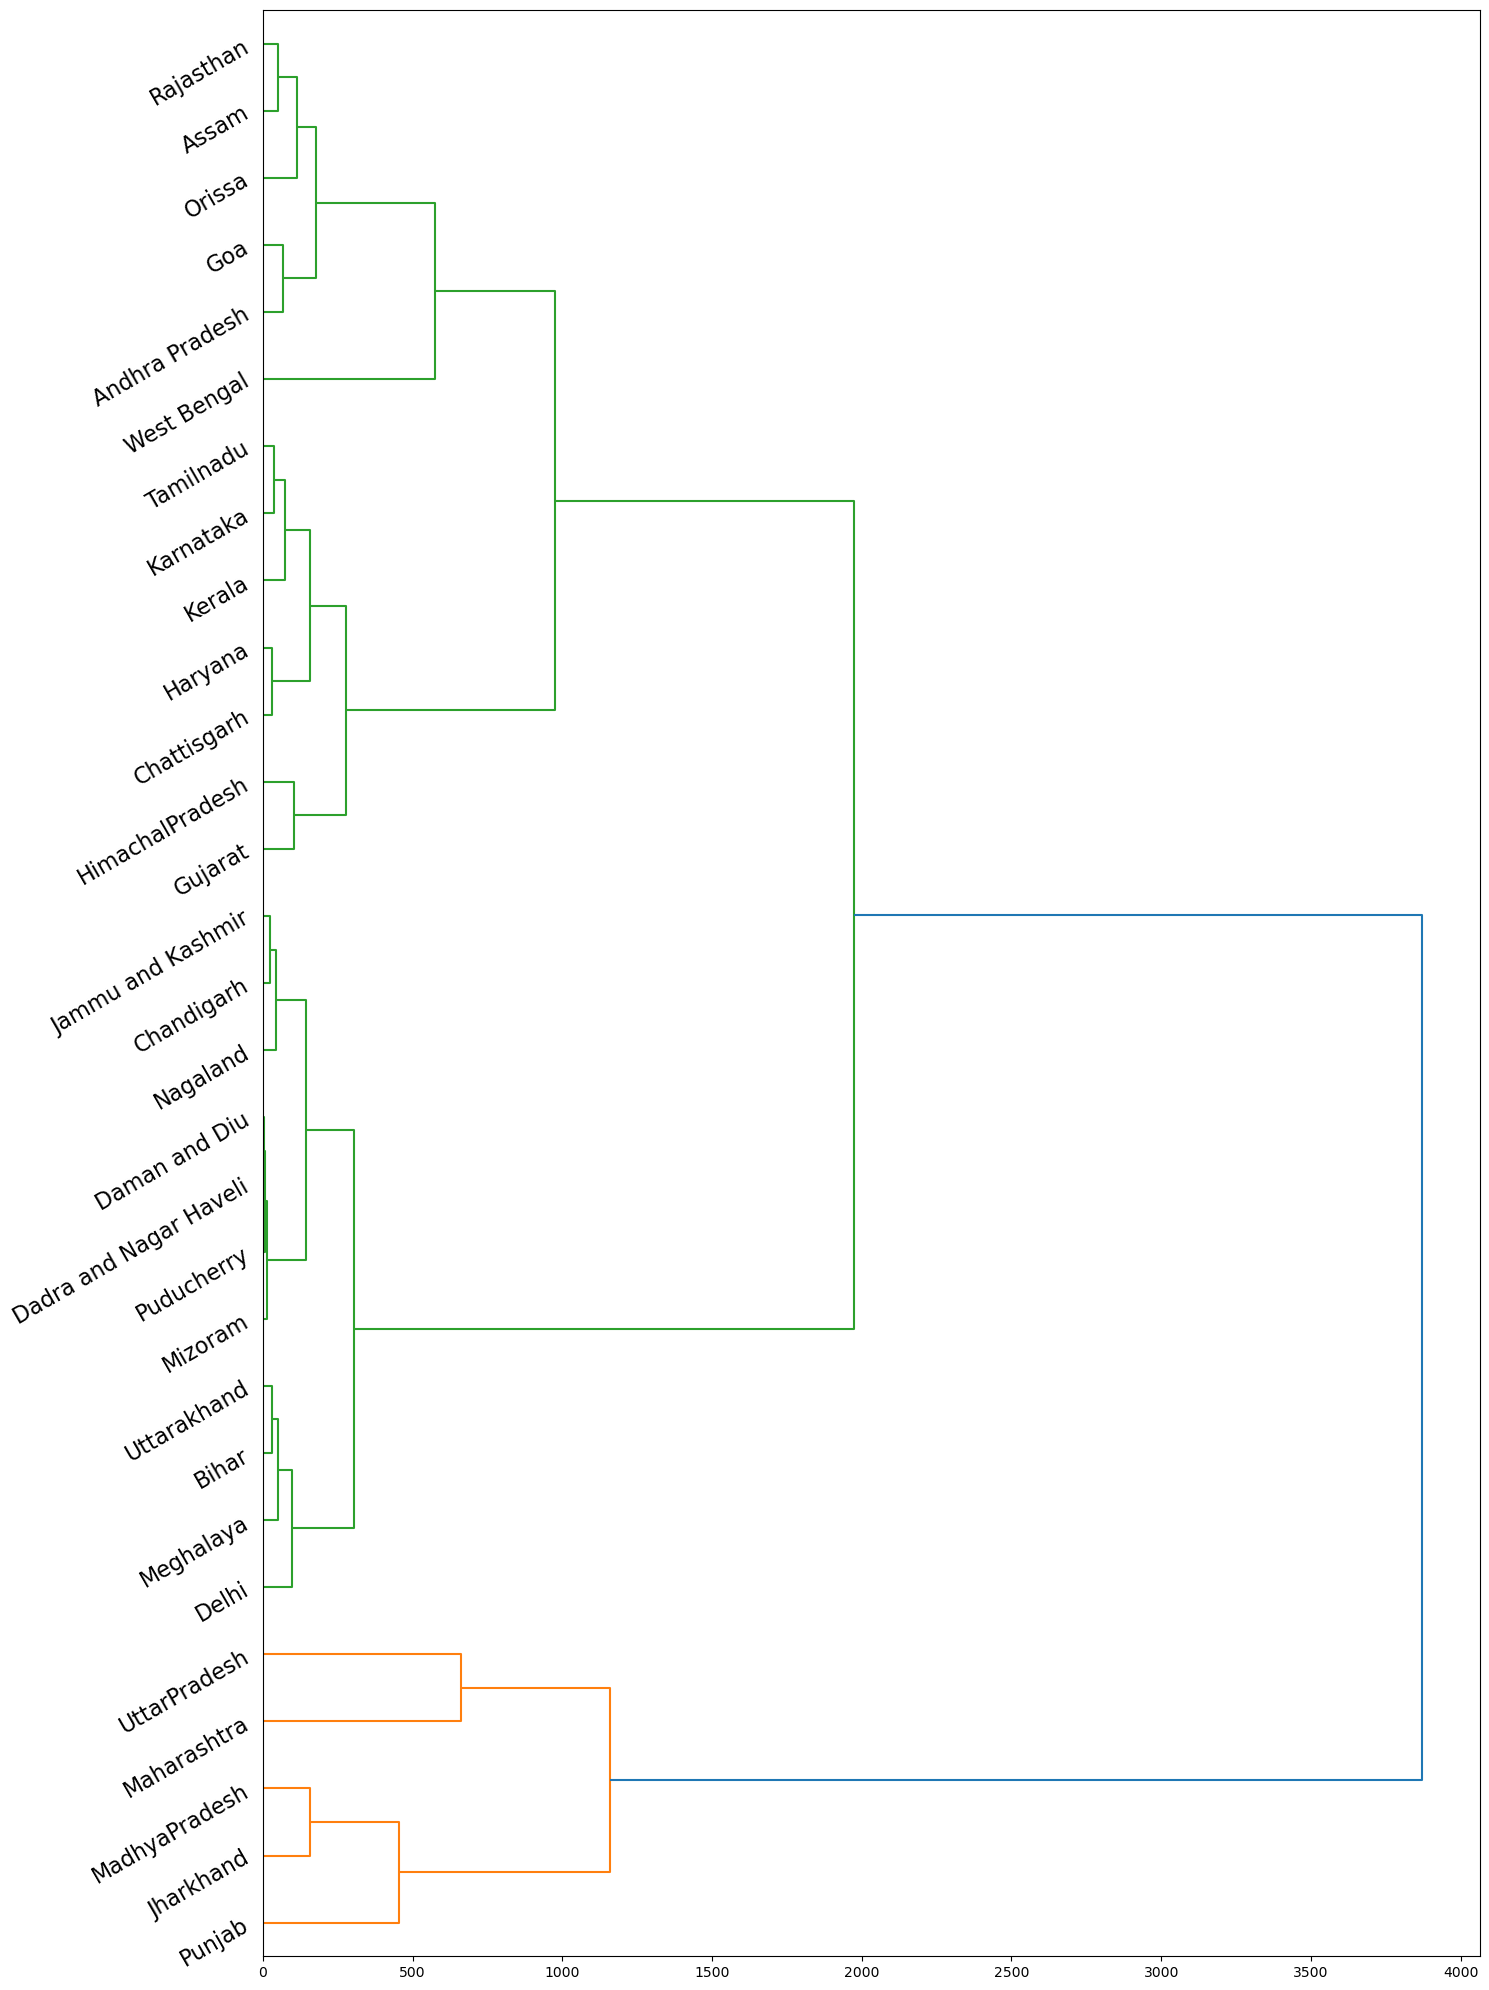

In [28]:
fig, ax = plt.subplots(figsize=(15,20))
ax=dendrogram(Z,orientation="right",labels=np.array(data_pol['State']),leaf_rotation=30,leaf_font_size=16)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.cluster import AgglomerativeClustering 

In [31]:
cluster = AgglomerativeClustering(n_clusters=9)

In [32]:
labels = cluster.fit_predict(data_scaled)
labels.shape

(29,)

In [34]:
from sklearn.metrics import silhouette_score
silhouette_score(data_scaled,labels,random_state=200)

0.472875365397902

In [36]:
for i in range(9,15):
    labels=AgglomerativeClustering(n_clusters=i).fit(data_scaled).labels_
    print ("Silhoutte score for k= "+str(i)+" is "+str(silhouette_score(data_scaled,labels,random_state=200)))

Silhoutte score for k= 9 is 0.472875365397902
Silhoutte score for k= 10 is 0.438603883048921
Silhoutte score for k= 11 is 0.3984136639698235
Silhoutte score for k= 12 is 0.3599026132582126
Silhoutte score for k= 13 is 0.35387280483759886
Silhoutte score for k= 14 is 0.36282071540857413


In [37]:
cluster = AgglomerativeClustering(n_clusters=11)
labels = cluster.fit_predict(data_scaled)
labels

array([10,  2,  3,  4,  1,  4,  4,  3, 10,  9,  1,  9,  4,  0,  1,  1,  0,
        5,  3,  4,  4,  2,  4,  7,  2,  1,  8,  3,  6])